In [1]:
from nsepy import get_history as gh
import datetime as dt # 1 hr data only not less than that.
import yfinance as yf

In [2]:
start = dt.datetime(2013,1,1)
end = dt.datetime(2023,1,1)
stk_data = yf.download("RELIANCE.NS", start=start, end=end)

[*********************100%***********************]  1 of 1 completed


In [3]:
stk_data

Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2013-01-01,176.018585,177.253884,175.683586,176.709519,6831351
2013-01-02,177.536530,179.221978,176.405928,176.709522,13441898
2013-01-03,180.216492,180.478199,176.835141,177.672617,17266808
2013-01-04,180.446793,181.022562,178.709017,180.457261,13306377
2013-01-07,179.347610,182.362558,178.342628,181.252893,15307180
...,...,...,...,...,...
2022-12-26,1152.220215,1160.414342,1137.772122,1147.974874,5990242
2022-12-27,1161.646973,1163.518550,1148.203131,1154.936462,5763271


In [4]:
dataset=stk_data
dataset.columns

MultiIndex([( 'Close', 'RELIANCE.NS'),
            (  'High', 'RELIANCE.NS'),
            (   'Low', 'RELIANCE.NS'),
            (  'Open', 'RELIANCE.NS'),
            ('Volume', 'RELIANCE.NS')],
           names=['Price', 'Ticker'])

In [5]:
dataset.columns = dataset.columns.get_level_values(0)
dataset.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')

In [6]:
ohlc = stk_data[["Open", "High", "Low", "Close"]]
ohlc

Price,Open,High,Low,Close
Date,,,,
2013-01-01,176.709519,177.253884,175.683586,176.018585
2013-01-02,176.709522,179.221978,176.405928,177.536530
2013-01-03,177.672617,180.478199,176.835141,180.216492
2013-01-04,180.457261,181.022562,178.709017,180.446793
2013-01-07,181.252893,182.362558,178.342628,179.347610
...,...,...,...,...
2022-12-26,1147.974874,1160.414342,1137.772122,1152.220215
2022-12-27,1154.936462,1163.518550,1148.203131,1161.646973
2022-12-28,1158.588423,1163.975064,1151.056230,1161.532837


In [7]:
ohlc.index.name = "Date"

In [8]:
ohlc.to_csv("reliance_ohlc2.csv")

In [9]:
#importing the dataset
import pandas as pd
dataset = pd.read_csv("reliance_ohlc2.csv",parse_dates=['Date'],index_col='Date')
dataset

,Open,High,Low,Close
Date,,,,
2013-01-01,176.709519,177.253884,175.683586,176.018585
2013-01-02,176.709522,179.221978,176.405928,177.536530
2013-01-03,177.672617,180.478199,176.835141,180.216492
2013-01-04,180.457261,181.022562,178.709017,180.446793
2013-01-07,181.252893,182.362558,178.342628,179.347610
...,...,...,...,...
2022-12-26,1147.974874,1160.414342,1137.772122,1152.220215
2022-12-27,1154.936462,1163.518550,1148.203131,1161.646973
2022-12-28,1158.588423,1163.975064,1151.056230,1161.532837


In [10]:
#Start date and end_date, converting the "2013-01-01" into timestap object using to_datetime
from datetime import date, timedelta
import pandas as pd
start_date = pd.to_datetime("2013-01-01")
#timedelta used to add /subtract the days, here we excluding last
end_date = pd.to_datetime("2023-01-01") - timedelta(days=1) 
#data_range creates a continuous sequence of dates. Here freq='d' means daily frequency including weekends and holidays.
all_date = pd.date_range(start_date, end_date, freq='d')

In [11]:
all_date

DatetimeIndex(['2013-01-01', '2013-01-02', '2013-01-03', '2013-01-04',
               '2013-01-05', '2013-01-06', '2013-01-07', '2013-01-08',
               '2013-01-09', '2013-01-10',
               ...
               '2022-12-22', '2022-12-23', '2022-12-24', '2022-12-25',
               '2022-12-26', '2022-12-27', '2022-12-28', '2022-12-29',
               '2022-12-30', '2022-12-31'],
              dtype='datetime64[ns]', length=3652, freq='D')

In [12]:
#Here we connectig the dataset with sequence dates
dummyDate = dataset.reindex(all_date) # this connects dataset with date_range (all_date)
dummyDate = dummyDate.fillna(method='ffill') #Holiday days and weekends i.e NAN value will get previous trading day's value.
dummyDate 

C:\Users\PAVAN\AppData\Local\Temp\ipykernel_30416\818050340.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  dummyDate = dummyDate.fillna(method='ffill') #Holiday days and weekends i.e NAN value will get previous trading day's value.


,Open,High,Low,Close
2013-01-01,176.709519,177.253884,175.683586,176.018585
2013-01-02,176.709522,179.221978,176.405928,177.536530
2013-01-03,177.672617,180.478199,176.835141,180.216492
2013-01-04,180.457261,181.022562,178.709017,180.446793
2013-01-05,180.457261,181.022562,178.709017,180.446793
...,...,...,...,...
2022-12-27,1154.936462,1163.518550,1148.203131,1161.646973
2022-12-28,1158.588423,1163.975064,1151.056230,1161.532837
2022-12-29,1153.566904,1163.564145,1152.882149,1161.007812
2022-12-30,1161.829476,1176.391675,1160.003541,1162.788086


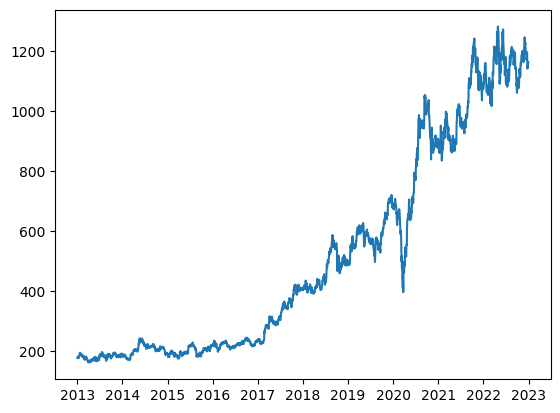

In [13]:
import matplotlib.pyplot as plt
plt.plot(dataset["Close"])

<Figure size 1600x500 with 0 Axes>

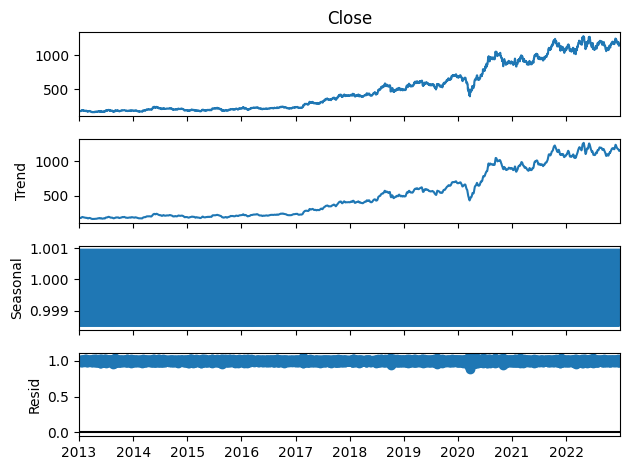

In [14]:
# Here we plot seasonal decompose i.e four components orignial, trend, seasonal and residual by multiplication model
from pandas import read_csv
from matplotlib import pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(dummyDate["Close"], model='multiplicative')
plt.figure(figsize=(16,5))
result.plot()
plt.show()

<Figure size 1600x500 with 0 Axes>

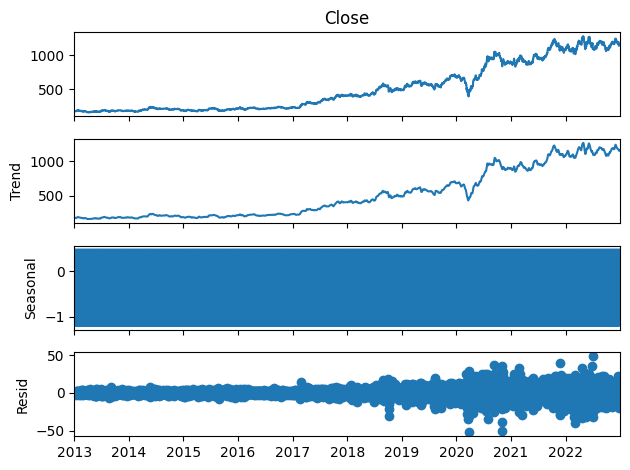

In [15]:
# Here we plot seasonal decompose i.e four components orignial, trend, seasonal and residual by additive model
from pandas import read_csv
from matplotlib import pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(dummyDate["Close"], model='additive')
plt.figure(figsize=(16,5))
result.plot()
plt.show()

Results of Dickey-Fuller Test:
Test statistic                    0.030491
p-value                           0.960982
#Lags Used                       19.000000
Number of Observations Used    3632.000000
Critical Value(1%)               -3.432152
Critical Value(5%)               -2.862336
Critical Value(10%)              -2.567194
dtype: float64

Condition:
p-value <= 0.05 → Reject Null Hypothesis (Stationary)
p-value > 0.05 → Fail to Reject Null (Non-Stationary)

Fails to Reject Null Hypothesis
Data is Non-Stationary


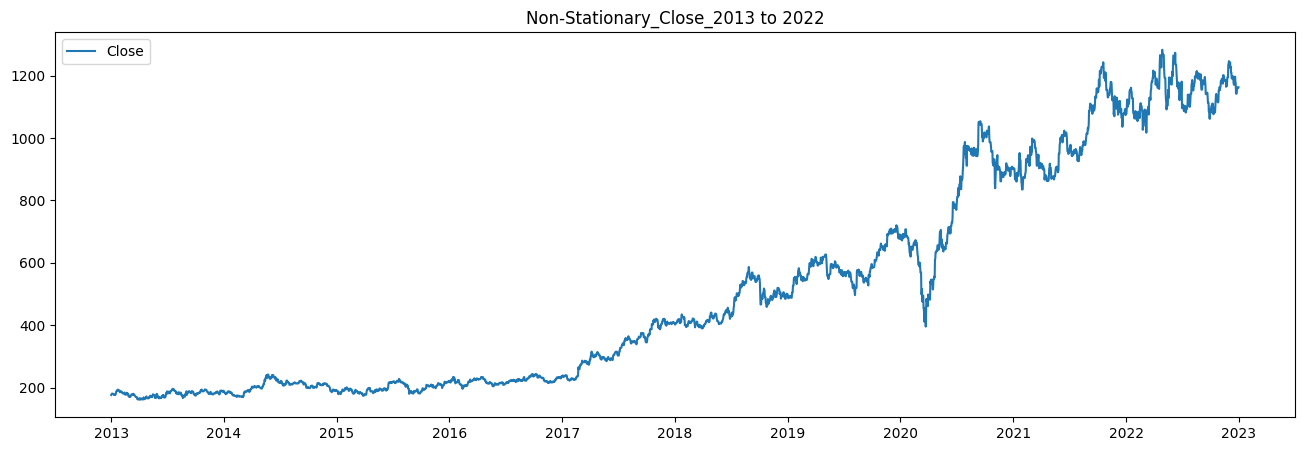

In [16]:
#Augmented dicky fuller test
from statsmodels.tsa.stattools import adfuller #important library to perform ADF

#1.Select series 
timeseries = dummyDate["Close"]
#2.perform ADF test
print("Results of Dickey-Fuller Test:")
dftest = adfuller(timeseries,autolag='AIC')

#3.Store output
dfoutput = pd.Series(dftest[0:4], index=['Test statistic','p-value','#Lags Used','Number of Observations Used'])

#4.Add critical values from dftest,index is 4.
for key,value in dftest[4].items():
    dfoutput[f'Critical Value({key})']=value
print(dfoutput)

#5.Hypothesis Decision
print("\nCondition:")
print("p-value <= 0.05 → Reject Null Hypothesis (Stationary)")
print("p-value > 0.05 → Fail to Reject Null (Non-Stationary)")

if(dfoutput['Test statistic'] < dfoutput['Critical Value(1%)'] or dfoutput['Test statistic'] < dfoutput['Critical Value(5%)'] or dfoutput['Test statistic'] < dfoutput['Critical Value(10%)'] or dfoutput['p-value'] <= 0.05):
    print("\nReject Null Hypothesis")
    print("Data is Stationary")
    message= "Stationary"
else:
    print("\nFails to Reject Null Hypothesis")
    print("Data is Non-Stationary")
    message="Non-Stationary"

# 6️.Plot
plt.figure(figsize=(16,5))
plt.plot(dummyDate.index, dummyDate["Close"], label="Close")
plt.legend()
plt.title(f"{message}_Close_2013 to 2022")
plt.savefig("Close_ADF.png")
plt.show()

In [17]:
#Since data is non stationarity we are using difference and log method to convert the data to stationarity
#taking log for reliance close data
import numpy as np
dummyDate['Log_Close'] = np.log(dummyDate['Close'])
#taking difference for the log_close data
dummyDate['Log_Diff_Close'] = dummyDate['Log_Close'].diff()

In [18]:
#check there is a null value in dummyDate 
dummyDate.isnull().sum()

Open              0
High              0
Low               0
Close             0
Log_Close         0
Log_Diff_Close    1
dtype: int64

In [19]:
#drop the null value
dummyDate.dropna(inplace= True)

In [20]:
dummyDate.isnull().sum()

Open              0
High              0
Low               0
Close             0
Log_Close         0
Log_Diff_Close    0
dtype: int64

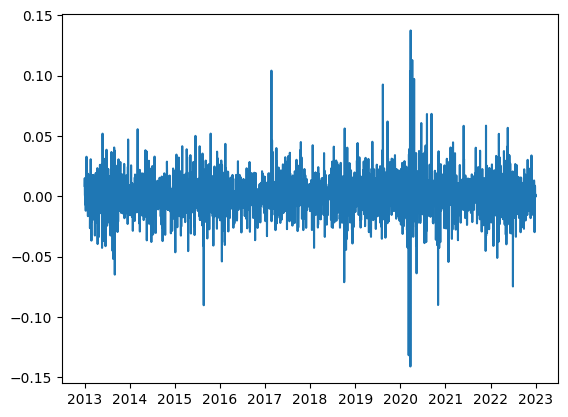

In [21]:
import matplotlib.pyplot as plt
plt.plot(dummyDate["Log_Diff_Close"])

<Figure size 1600x500 with 0 Axes>

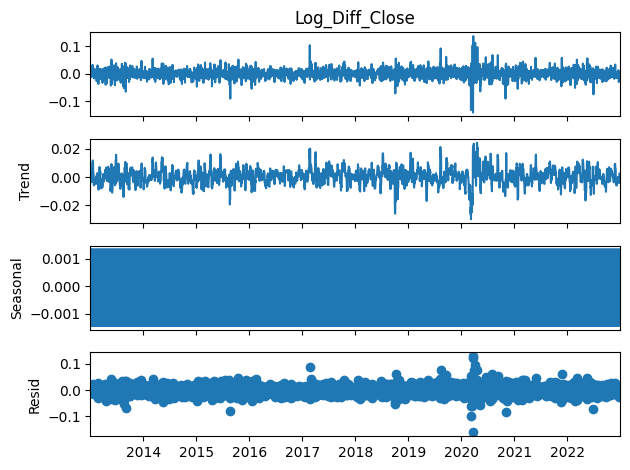

In [22]:
# Here we plot seasonal decompose i.e four components orignial, trend, seasonal and residual by additive model
from pandas import read_csv
from matplotlib import pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(dummyDate["Log_Diff_Close"], model='additive')
plt.figure(figsize=(16,5))
result.plot()
plt.show()

Results of Dickey-Fuller Test:
Test statistic                -1.327303e+01
p-value                        7.966579e-25
#Lags Used                     1.800000e+01
Number of Observations Used    3.632000e+03
Critical Value(1%)            -3.432152e+00
Critical Value(5%)            -2.862336e+00
Critical Value(10%)           -2.567194e+00
dtype: float64

Condition:
p-value <= 0.05 → Reject Null Hypothesis (Stationary)
p-value > 0.05 → Fail to Reject Null (Non-Stationary)

Reject Null Hypothesis
Data is Stationary


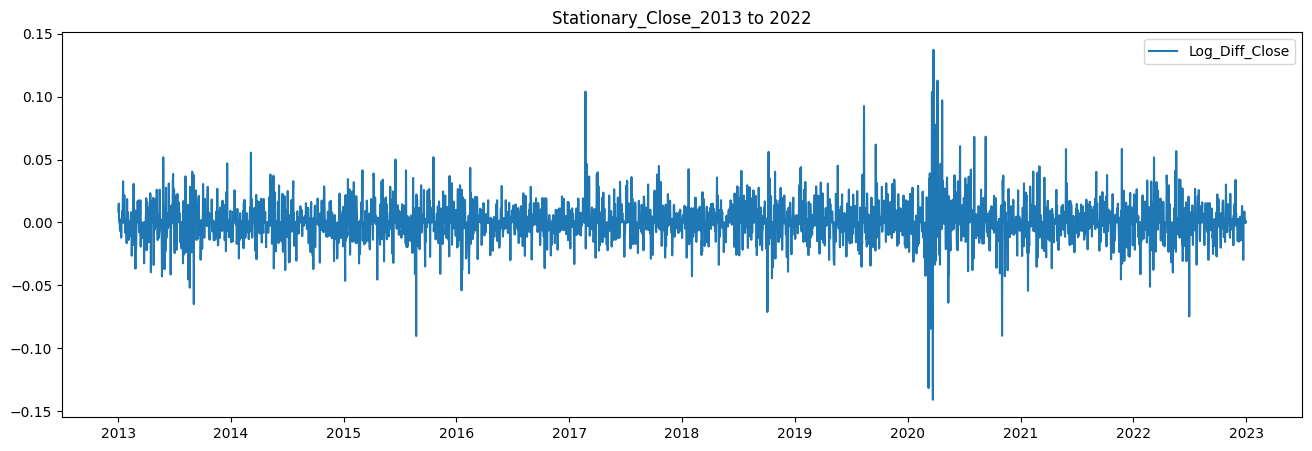

In [25]:
#1.Select series 
timeseries = dummyDate["Log_Diff_Close"]

#2.perform ADF test
print("Results of Dickey-Fuller Test:")
dftest = adfuller(timeseries,autolag='AIC')

#3.Store output
dfoutput = pd.Series(dftest[0:4], index=['Test statistic','p-value','#Lags Used','Number of Observations Used'])

#4.Add critical values from dftest,index is 4.
for key,value in dftest[4].items():
    dfoutput[f'Critical Value({key})']=value
print(dfoutput)

#5.Hypothesis Decision
print("\nCondition:")
print("p-value <= 0.05 → Reject Null Hypothesis (Stationary)")
print("p-value > 0.05 → Fail to Reject Null (Non-Stationary)")

if(dfoutput['Test statistic'] < dfoutput['Critical Value(1%)'] or dfoutput['Test statistic'] < dfoutput['Critical Value(5%)'] or dfoutput['Test statistic'] < dfoutput['Critical Value(10%)'] or dfoutput['p-value'] <= 0.05):
    print("\nReject Null Hypothesis")
    print("Data is Stationary")
    message= "Stationary"
else:
    print("\nFails to Reject Null Hypothesis")
    print("Data is Non-Stationary")
    message="Non-Stationary"

# 6️.Plot
plt.figure(figsize=(16,5))
plt.plot(dummyDate.index, dummyDate["Log_Diff_Close"], label="Log_Diff_Close")
plt.legend()
plt.title(f"{message}_Close_2013 to 2022")
plt.savefig("Close_ADF.png")
plt.show()

In [29]:
#Autocorrelation - Autocorrelation measures how strongly a time series is correlated with its own past values.
#partial Autocorrelation - Partial Autocorrelation removes indirect effects.


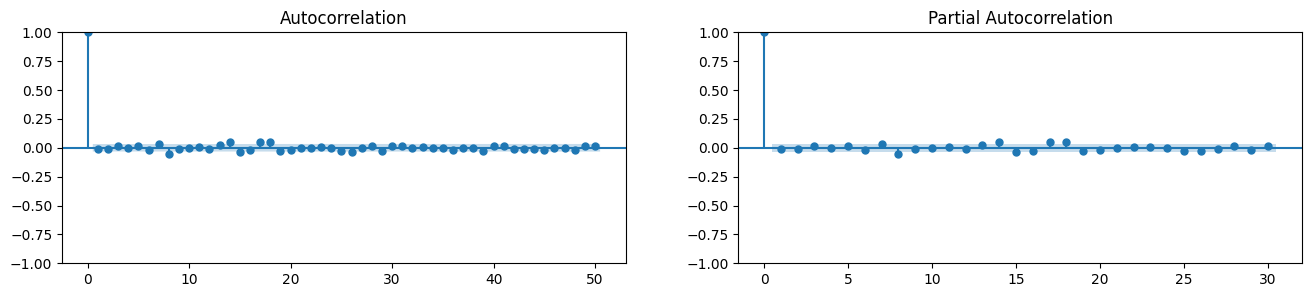

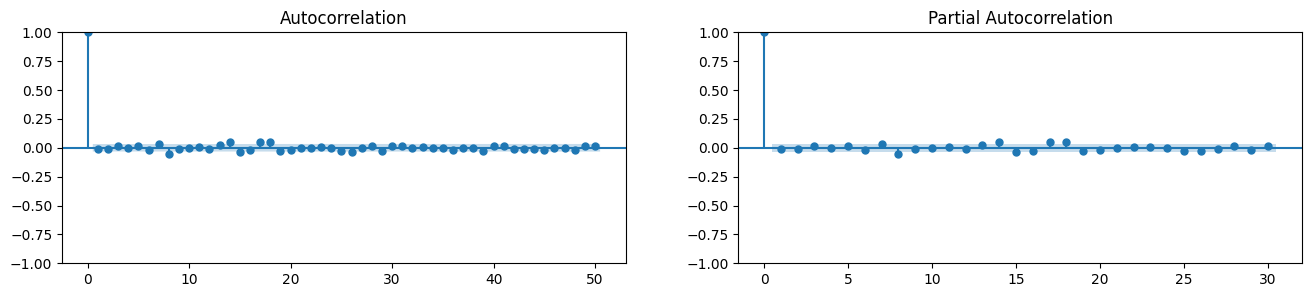

In [27]:
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1,2,figsize=(16,3), dpi= 100)
plot_acf(dummyDate["Log_Diff_Close"], lags=50, ax=axes[0])
plot_pacf(dummyDate["Log_Diff_Close"], lags=30, ax=axes[1])

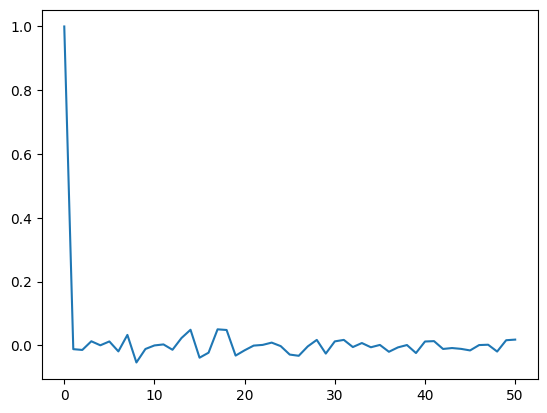

In [30]:
plt.plot(acf(dummyDate["Log_Diff_Close"],nlags=50))

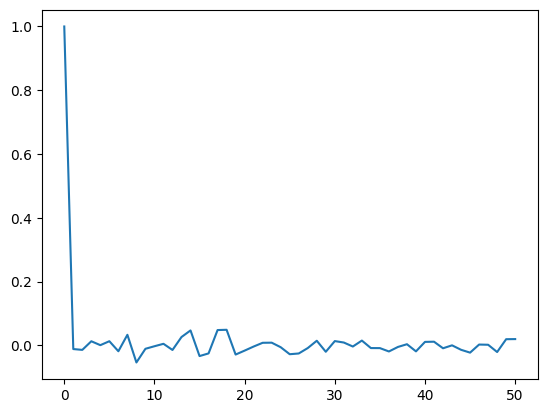

In [31]:
plt.plot(pacf(dummyDate["Log_Diff_Close"],nlags=50))

<Axes: xlabel='y(t)', ylabel='y(t + 1)'>

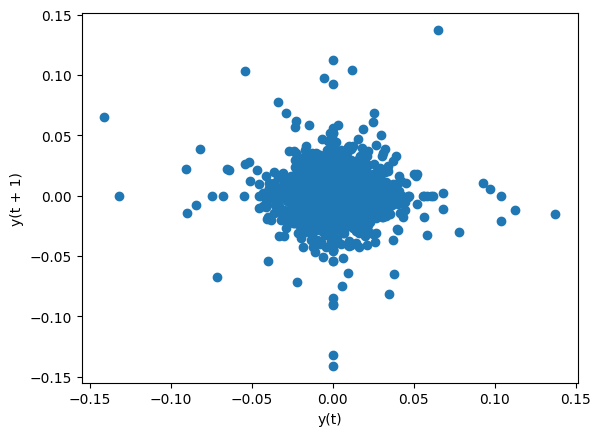

In [32]:
from pandas.plotting import lag_plot
lag_plot(dummyDate["Log_Diff_Close"],lag=1)

## Forecastability - refers to how reliably and accurately future values of a variable can be predicted using historical data.It depends on trend, seasonality and residual.
## High forecastability used in electrical demand, weather forecasting, rainfall rate. Low forecastability used in stock market, Lottery number and pure randomness.
## In statistics, forecastability is linked to:Variance explained by the model,Signal-to-noise ratio,Autocorrelation strength and Entropy (lower entropy → higher forecastability)

## For example:If ACF shows strong correlation → higher forecastability.If ADF test shows stationarity with strong structure → modelable.If residuals look like white noise → model captured most predictable structure.


## APEN - Approximate Entropy- Measure the probability that similar patterns of length m remain similar when length increases to m+1.If patterns continue consistently → predictable → low ApEn.If patterns break frequently → irregular → high ApEn. Limitation - Counts self-matches,Biased for small sample sizes, Not very consistent.
## SampEn (often written as SpEn informally) = Sample Entropy - Probability that similar sequences of length m stay similar at m+1. But mathematically cleaner. Imporvement over APEN, It Does NOT count self-matches, Less biased and More reliable for small datasets.
## Both measure regularity / unpredictability in time-series data.

In [37]:
#U → your time series (like Log_Diff_Close)
#m → pattern length
#r → tolerance level (similarity threshold)
def ApEn(U, m, r):
    """Compute Aproximate entropy"""
    #Calculate the maximum difference between two sequences.
    def _maxdist(x_i, x_j):
        return max([abs(ua - va) for ua, va in zip(x_i, x_j)])

    def _phi(m):
        x = [[U[j] for j in range(i, i + m - 1 + 1)] for i in range(N - m + 1)] #Creating Patterns of Length m
        C = [len([1 for x_j in x if _maxdist(x_i, x_j) <= r]) / (N - m + 1.0) for x_i in x]#Counting Similar Patterns
        return (N - m + 1.0)**(-1) * sum(np.log(C))

    N = len(U)
    return abs(_phi(m+1) - _phi(m))

In [38]:
import numpy as np
print(ApEn(dummyDate["Log_Diff_Close"], m=2, r=0.2*np.std(dummyDate["Log_Diff_Close"])))  

C:\Users\PAVAN\AppData\Local\Temp\ipykernel_30416\1385020485.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  x = [[U[j] for j in range(i, i + m - 1 + 1)] for i in range(N - m + 1)] #Creating Patterns of Length m


1.6772910094384041


In [39]:
def SampEn(U, m, r):
    """Compute Sample entropy"""
    def _maxdist(x_i, x_j):
        return max([abs(ua - va) for ua, va in zip(x_i, x_j)])

    def _phi(m):
        x = [[U[j] for j in range(i, i + m - 1 + 1)] for i in range(N - m + 1)]
        C = [len([1 for j in range(len(x)) if i != j and _maxdist(x[i], x[j]) <= r]) for i in range(len(x))]
        return sum(C)

    N = len(U)
    return -np.log(_phi(m+1) / _phi(m))

In [41]:
print(SampEn(dummyDate["Log_Diff_Close"], m=2, r=0.2*np.std(dummyDate["Log_Diff_Close"])))

C:\Users\PAVAN\AppData\Local\Temp\ipykernel_30416\1392444303.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  x = [[U[j] for j in range(i, i + m - 1 + 1)] for i in range(N - m + 1)]


1.6389117609005937
